In [ ]:
# Step 0 — Install all required project libraries and mount Google Drive for saved model checkpoints

!pip -q install gradio joblib scikit-learn scipy

# Core Python libraries used throughout the project
import os
import math
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning libraries
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score,
    classification_report
)

# Probability / statistics
from scipy.stats import norm

# Google Drive
from google.colab import drive

drive.mount('/content/drive')

# Folder for saving trained models and project files
CHECKPOINT_DIR = "/content/drive/MyDrive/Leave_By_Project"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("========================================")
print("Leave-By Project Environment Ready ✅")
print("Google Drive:", CHECKPOINT_DIR)
print("========================================")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Leave-By Project Environment Ready ✅
Google Drive: /content/drive/MyDrive/Leave_By_Project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving weather_data_nyc_centralpark_2016(1).csv to weather_data_nyc_centralpark_2016(1) (1).csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.zip to train (1).zip


In [ ]:
zip_path = "/content/train.zip"
extract_path = "/content/nyc_taxi"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Taxi dataset extracted")
print(os.listdir(extract_path))

Taxi dataset extracted
['train.csv']


In [ ]:
taxi_path = "/content/nyc_taxi/train.csv"

taxi = pd.read_csv(taxi_path)

print("Shape:", taxi.shape)
taxi.head()

Shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [ ]:
weather_path = "/content/weather_data_nyc_centralpark_2016(1).csv"

weather = pd.read_csv(weather_path)

print("Shape:", weather.shape)
weather.head()

Shape: (366, 7)


,date,maximum temperature,minimum temperature,average temperature,precipitation,snow fall,snow depth
0,1-1-2016,42,34,38.0,0.00,0.0,0
1,2-1-2016,40,32,36.0,0.00,0.0,0
2,3-1-2016,45,35,40.0,0.00,0.0,0
3,4-1-2016,36,14,25.0,0.00,0.0,0
4,5-1-2016,29,11,20.0,0.00,0.0,0


In [ ]:
print("Taxi columns:")
print(taxi.columns.tolist())

print("\nWeather columns:")
print(weather.columns.tolist())

Taxi columns:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']

Weather columns:
['date', 'maximum temperature', 'minimum temperature', 'average temperature', 'precipitation', 'snow fall', 'snow depth']


In [ ]:
taxi['pickup_datetime'] = pd.to_datetime(
    taxi['pickup_datetime'],
    errors='coerce'
)

taxi['dropoff_datetime'] = pd.to_datetime(
    taxi['dropoff_datetime'],
    errors='coerce'
)

print("Invalid pickup times:", taxi['pickup_datetime'].isna().sum())
print("Invalid dropoff times:", taxi['dropoff_datetime'].isna().sum())

Invalid pickup times: 0
Invalid dropoff times: 0


In [ ]:
taxi['pickup_date'] = taxi['pickup_datetime'].dt.date

taxi['hour'] = taxi['pickup_datetime'].dt.hour
taxi['weekday'] = taxi['pickup_datetime'].dt.day_name()
taxi['weekday_num'] = taxi['pickup_datetime'].dt.dayofweek

taxi['is_weekend'] = (taxi['weekday_num'] >= 5).astype(int)

taxi['is_peak_hour'] = (
    taxi['hour'].between(7, 9) |
    taxi['hour'].between(16, 19)
).astype(int)

taxi[['pickup_datetime', 'hour', 'weekday',
      'is_weekend', 'is_peak_hour']].head()

,pickup_datetime,hour,weekday,is_weekend,is_peak_hour
0,2016-03-14 17:24:55,17,Monday,0,1
1,2016-06-12 00:43:35,0,Sunday,1,0
2,2016-01-19 11:35:24,11,Tuesday,0,0
3,2016-04-06 19:32:31,19,Wednesday,0,1
4,2016-03-26 13:30:55,13,Saturday,1,0


In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


taxi['distance_km'] = haversine_distance(
    taxi['pickup_latitude'],
    taxi['pickup_longitude'],
    taxi['dropoff_latitude'],
    taxi['dropoff_longitude']
)

# Convert duration from seconds to minutes
taxi['travel_time_min'] = taxi['trip_duration'] / 60

print(taxi[
    ['passenger_count',
     'hour',
     'is_peak_hour',
     'distance_km',
     'travel_time_min']
].head())

   passenger_count  hour  is_peak_hour  distance_km  travel_time_min
0                1    17             1     1.498521         7.583333
1                1     0             0     1.805507        11.050000
2                1    11             0     6.385098        35.400000
3                1    19             1     1.485498         7.150000
4                1    13             0     1.188588         7.250000


In [ ]:
taxi = taxi[
    (taxi['travel_time_min'] > 1) &
    (taxi['travel_time_min'] < 180) &
    (taxi['distance_km'] > 0.2) &
    (taxi['distance_km'] < 100)
].copy()

print("Remaining rows:", len(taxi))

Remaining rows: 1437554


In [ ]:
# Step 11 — Convert the weather date column into a proper date for merging with taxi trips
weather['date'] = pd.to_datetime(
    weather['date'],
    dayfirst=True,
    errors='coerce'
)

print(weather['date'].head())
print("Invalid dates:", weather['date'].isna().sum())

0   2016-01-01
1   2016-01-02
2   2016-01-03
3   2016-01-04
4   2016-01-05
Name: date, dtype: datetime64[ns]
Invalid dates: 0


In [ ]:
# Step 12 — Rename weather columns so they are easier to use in Python
weather = weather.rename(columns={
    'maximum temperature': 'max_temp',
    'minimum temperature': 'min_temp',
    'average temperature': 'avg_temp',
    'precipitation': 'precipitation',
    'snow fall': 'snowfall',
    'snow depth': 'snow_depth'
})

print(weather.columns.tolist())

['date', 'max_temp', 'min_temp', 'avg_temp', 'precipitation', 'snowfall', 'snow_depth']


In [ ]:
# Step 13 — Convert weather measurements to numeric values and handle trace values
weather_numeric = ['max_temp', 'min_temp', 'avg_temp',
                   'precipitation', 'snowfall', 'snow_depth']

for col in weather_numeric:
    weather[col] = weather[col].replace('T', '0')
    weather[col] = pd.to_numeric(weather[col], errors='coerce')
    weather[col] = weather[col].fillna(0)

print(weather[weather_numeric].dtypes)

max_temp           int64
min_temp           int64
avg_temp         float64
precipitation    float64
snowfall         float64
snow_depth         int64
dtype: object


In [ ]:
# Step 14 — Create rain and snow indicators that we can use in probability and ML
weather['is_rain'] = (weather['precipitation'] > 0).astype(int)
weather['is_snow'] = (weather['snowfall'] > 0).astype(int)

print(weather[['date', 'avg_temp', 'precipitation',
               'snowfall', 'is_rain', 'is_snow']].head(10))

        date  avg_temp  precipitation  snowfall  is_rain  is_snow
0 2016-01-01      38.0            0.0       0.0        0        0
1 2016-01-02      36.0            0.0       0.0        0        0
2 2016-01-03      40.0            0.0       0.0        0        0
3 2016-01-04      25.0            0.0       0.0        0        0
4 2016-01-05      20.0            0.0       0.0        0        0
5 2016-01-06      33.0            0.0       0.0        0        0
6 2016-01-07      38.5            0.0       0.0        0        0
7 2016-01-08      38.5            0.0       0.0        0        0
8 2016-01-09      43.5            0.0       0.0        0        0
9 2016-01-10      49.5            1.8       0.0        1        0


In [ ]:
# Step 15 — Create a date-only column in the taxi dataset for matching daily weather
taxi['date'] = taxi['pickup_datetime'].dt.normalize()

print(taxi[['pickup_datetime', 'date']].head())

      pickup_datetime       date
0 2016-03-14 17:24:55 2016-03-14
1 2016-06-12 00:43:35 2016-06-12
2 2016-01-19 11:35:24 2016-01-19
3 2016-04-06 19:32:31 2016-04-06
4 2016-03-26 13:30:55 2016-03-26


In [ ]:
# Step 16 — Merge each taxi trip with the weather recorded on its pickup date
taxi_weather = taxi.merge(
    weather,
    on='date',
    how='left'
)

print("Merged shape:", taxi_weather.shape)
print(taxi_weather[
    ['pickup_datetime', 'travel_time_min',
     'avg_temp', 'precipitation',
     'snowfall', 'is_rain', 'is_snow']
].head())

Merged shape: (1437554, 28)
      pickup_datetime  travel_time_min  avg_temp  precipitation  snowfall  \
0 2016-03-14 17:24:55         7.583333      45.5           0.29       0.0   
1 2016-06-12 00:43:35        11.050000      72.5           0.00       0.0   
2 2016-01-19 11:35:24        35.400000      22.0           0.00       0.0   
3 2016-04-06 19:32:31         7.150000      39.0           0.00       0.0   
4 2016-03-26 13:30:55         7.250000      46.5           0.00       0.0   

   is_rain  is_snow  
0        1        0  
1        0        0  
2        0        0  
3        0        0  
4        0        0  


In [ ]:
# Step 17 — Check for missing weather values after the taxi-weather merge
missing_weather = taxi_weather['avg_temp'].isna().sum()

print("Trips without weather data:", missing_weather)
print("Total trips:", len(taxi_weather))

Trips without weather data: 0
Total trips: 1437554


In [ ]:
# Step 18 — Create a simple travel-condition category using peak hours and weather
taxi_weather['condition'] = np.select(
    [
        (taxi_weather['is_rain'] == 1) & (taxi_weather['is_peak_hour'] == 1),
        (taxi_weather['is_rain'] == 1) & (taxi_weather['is_peak_hour'] == 0),
        (taxi_weather['is_rain'] == 0) & (taxi_weather['is_peak_hour'] == 1)
    ],
    [
        'Rain + Peak',
        'Rain + Off-Peak',
        'Dry + Peak'
    ],
    default='Dry + Off-Peak'
)

print(taxi_weather['condition'].value_counts())

condition
Dry + Off-Peak     636136
Dry + Peak         343965
Rain + Off-Peak    296392
Rain + Peak        161061
Name: count, dtype: int64


In [ ]:
# Step 19 — Create the final project table containing the variables needed for Unit 1
project_df = taxi_weather[
    [
        'id',
        'pickup_datetime',
        'dropoff_datetime',
        'hour',
        'weekday',
        'weekday_num',
        'is_weekend',
        'is_peak_hour',
        'passenger_count',
        'pickup_longitude',
        'pickup_latitude',
        'dropoff_longitude',
        'dropoff_latitude',
        'distance_km',
        'travel_time_min',
        'avg_temp',
        'max_temp',
        'min_temp',
        'precipitation',
        'snowfall',
        'is_rain',
        'is_snow',
        'condition'
    ]
].copy()

print("Project dataset shape:", project_df.shape)
project_df.head()

Project dataset shape: (1437554, 23)


,id,pickup_datetime,dropoff_datetime,hour,weekday,weekday_num,is_weekend,is_peak_hour,passenger_count,pickup_longitude,...,distance_km,travel_time_min,avg_temp,max_temp,min_temp,precipitation,snowfall,is_rain,is_snow,condition
0,id2875421,2016-03-14 17:24:55,2016-03-14 17:32:30,17,Monday,0,0,1,1,-73.982155,...,1.498521,7.583333,45.5,51,40,0.29,0.0,1,0,Rain + Peak
1,id2377394,2016-06-12 00:43:35,2016-06-12 00:54:38,0,Sunday,6,1,0,1,-73.980415,...,1.805507,11.050000,72.5,83,62,0.00,0.0,0,0,Dry + Off-Peak
2,id3858529,2016-01-19 11:35:24,2016-01-19 12:10:48,11,Tuesday,1,0,0,1,-73.979027,...,6.385098,35.400000,22.0,28,16,0.00,0.0,0,0,Dry + Off-Peak
3,id3504673,2016-04-06 19:32:31,2016-04-06 19:39:40,19,Wednesday,2,0,1,1,-74.010040,...,1.485498,7.150000,39.0,48,30,0.00,0.0,0,0,Dry + Peak
4,id2181028,2016-03-26 13:30:55,2016-03-26 13:38:10,13,Saturday,5,1,0,1,-73.973053,...,1.188588,7.250000,46.5,55,38,0.00,0.0,0,0,Dry + Off-Peak


In [ ]:
# Step 20 — Create a 200,000-row working dataset and save it as a CSV file
project_df = project_df.sample(
    n=min(200000, len(project_df)),
    random_state=42
).sort_values('pickup_datetime').reset_index(drop=True)

project_df.to_csv(
    '/content/leave_by_dataset.csv',
    index=False
)

print("Final dataset shape:", project_df.shape)
print("Date range:",
      project_df['pickup_datetime'].min(),
      "to",
      project_df['pickup_datetime'].max())

print("\nRain distribution:")
print(project_df['is_rain'].value_counts())

print("\nPeak-hour distribution:")
print(project_df['is_peak_hour'].value_counts())

print("\nDataset saved as: leave_by_dataset.csv")

Final dataset shape: (200000, 23)
Date range: 2016-01-01 00:01:20 to 2016-06-30 23:59:39

Rain distribution:
is_rain
0    135916
1     64084
Name: count, dtype: int64

Peak-hour distribution:
is_peak_hour
0    129314
1     70686
Name: count, dtype: int64

Dataset saved as: leave_by_dataset.csv


In [ ]:
# Step 21 — Check whether any important project variables contain missing values
print(project_df.isnull().sum().sort_values(ascending=False).head(15))

id                   0
pickup_datetime      0
dropoff_datetime     0
hour                 0
weekday              0
weekday_num          0
is_weekend           0
is_peak_hour         0
passenger_count      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
distance_km          0
travel_time_min      0
dtype: int64


In [ ]:
# Step 22 — Calculate basic descriptive statistics for important numerical variables
print(project_df[['travel_time_min', 'distance_km', 'passenger_count',
                  'avg_temp', 'precipitation']].describe())

       travel_time_min    distance_km  passenger_count       avg_temp  \
count    200000.000000  200000.000000    200000.000000  200000.000000   
mean         14.071697       3.483856         1.664890      51.560758   
std          10.924777       3.949365         1.314656      15.642032   
min           1.016667       0.200009         1.000000       7.000000   
25%           6.716667       1.262877         1.000000      39.000000   
50%          11.150000       2.127578         1.000000      51.500000   
75%          17.983333       3.918069         2.000000      63.000000   
max         170.116667      90.677610         6.000000      81.500000   

       precipitation  
count  200000.000000  
mean        0.086309  
std         0.249360  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.040000  
max         2.310000  


In [ ]:
# Step 23 — Calculate the expected/average travel time in the dataset
mean_time = project_df['travel_time_min'].mean()

print(f"Mean travel time: {mean_time:.2f} minutes")

Mean travel time: 14.07 minutes


In [ ]:
# Step 24 — Calculate travel-time variance and standard deviation to measure uncertainty
variance_time = project_df['travel_time_min'].var()
std_time = project_df['travel_time_min'].std()

print(f"Variance: {variance_time:.2f}")
print(f"Standard deviation: {std_time:.2f} minutes")

Variance: 119.35
Standard deviation: 10.92 minutes


In [ ]:
# Step 25 — Calculate median, 75th percentile, and 90th percentile of travel time
quantiles = project_df['travel_time_min'].quantile([0.50, 0.75, 0.90])

print("Travel-time quantiles:")
print(quantiles)

Travel-time quantiles:
0.50    11.150000
0.75    17.983333
0.90    27.183333
Name: travel_time_min, dtype: float64


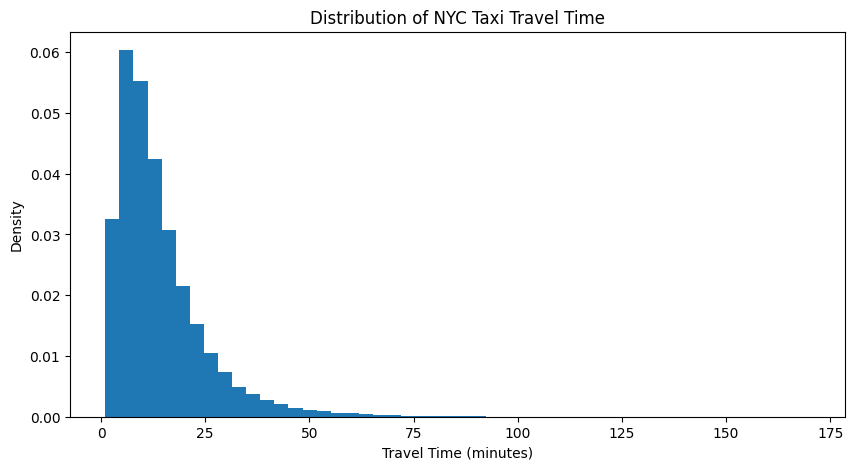

In [ ]:
# Step 26 — Visualize the distribution of travel times
plt.figure(figsize=(10, 5))

plt.hist(
    project_df['travel_time_min'],
    bins=50,
    density=True
)

plt.xlabel('Travel Time (minutes)')
plt.ylabel('Density')
plt.title('Distribution of NYC Taxi Travel Time')

plt.show()

In [ ]:
# Step 27 — Create discrete events for probability calculations
long_trip_threshold = project_df['travel_time_min'].quantile(0.75)

project_df['is_long_trip'] = (
    project_df['travel_time_min'] > long_trip_threshold
).astype(int)

print(f"Long-trip threshold: {long_trip_threshold:.2f} minutes")

print("\nLong trip counts:")
print(project_df['is_long_trip'].value_counts())

Long-trip threshold: 17.98 minutes

Long trip counts:
is_long_trip
0    150007
1     49993
Name: count, dtype: int64


In [ ]:
# Step 28 — Calculate marginal and joint probabilities using fundamental probability rules
p_rain = project_df['is_rain'].mean()
p_peak = project_df['is_peak_hour'].mean()
p_long = project_df['is_long_trip'].mean()

p_rain_and_long = (
    (project_df['is_rain'] == 1) &
    (project_df['is_long_trip'] == 1)
).mean()

p_peak_and_long = (
    (project_df['is_peak_hour'] == 1) &
    (project_df['is_long_trip'] == 1)
).mean()

print(f"P(Rain) = {p_rain:.4f}")
print(f"P(Peak) = {p_peak:.4f}")
print(f"P(Long Trip) = {p_long:.4f}")
print(f"P(Rain AND Long Trip) = {p_rain_and_long:.4f}")
print(f"P(Peak AND Long Trip) = {p_peak_and_long:.4f}")

P(Rain) = 0.3204
P(Peak) = 0.3534
P(Long Trip) = 0.2500
P(Rain AND Long Trip) = 0.0782
P(Peak AND Long Trip) = 0.0893


In [ ]:
# Step 29 — Calculate conditional probabilities and verify Bayes rule for rain and long trips
p_long_given_rain = (
    project_df.loc[project_df['is_rain'] == 1, 'is_long_trip']
).mean()

p_rain_given_long = (
    project_df.loc[project_df['is_long_trip'] == 1, 'is_rain']
).mean()

bayes_value = (
    p_long_given_rain * p_rain / p_long
)

print(f"P(Long Trip | Rain) = {p_long_given_rain:.4f}")
print(f"P(Rain | Long Trip) from data = {p_rain_given_long:.4f}")
print(f"P(Rain | Long Trip) using Bayes = {bayes_value:.4f}")

P(Long Trip | Rain) = 0.2440
P(Rain | Long Trip) from data = 0.3127
P(Rain | Long Trip) using Bayes = 0.3127


In [ ]:
# Step 30 — Calculate covariance between travel time, distance, temperature, and precipitation
covariance_matrix = project_df[
    ['travel_time_min', 'distance_km', 'avg_temp', 'precipitation']
].cov()

print("Covariance matrix:")
print(covariance_matrix)

Covariance matrix:
                 travel_time_min  distance_km    avg_temp  precipitation
travel_time_min       119.350750    33.333675    9.318771      -0.036224
distance_km            33.333675    15.597484    1.212960      -0.001997
avg_temp                9.318771     1.212960  244.673173       0.080691
precipitation          -0.036224    -0.001997    0.080691       0.062181


In [ ]:
# Step 31 — Split the trips chronologically so future trips are never used to predict earlier trips
split_index = int(len(project_df) * 0.80)

train_df = project_df.iloc[:split_index].copy()
test_df = project_df.iloc[split_index:].copy()

print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))

print("\nTraining period:")
print(train_df['pickup_datetime'].min(), "to", train_df['pickup_datetime'].max())

print("\nTesting period:")
print(test_df['pickup_datetime'].min(), "to", test_df['pickup_datetime'].max())

Training rows: 160000
Testing rows : 40000

Training period:
2016-01-01 00:01:20 to 2016-05-24 07:06:32

Testing period:
2016-05-24 07:09:16 to 2016-06-30 23:59:39


In [ ]:
# Step 32 — Select the variables that the model will use to predict travel time
features = [
    'hour',
    'weekday_num',
    'is_weekend',
    'is_peak_hour',
    'passenger_count',
    'distance_km',
    'avg_temp',
    'precipitation',
    'is_rain',
    'snowfall'
]

target = 'travel_time_min'

X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_test = test_df[features].copy()
y_test = test_df[target].copy()

print("Features:")
print(features)
print("\nTarget:", target)

Features:
['hour', 'weekday_num', 'is_weekend', 'is_peak_hour', 'passenger_count', 'distance_km', 'avg_temp', 'precipitation', 'is_rain', 'snowfall']

Target: travel_time_min


In [ ]:
# Step 33 — Train a supervised regression model to predict taxi travel time
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear regression model trained successfully.")

Linear regression model trained successfully.


In [ ]:
# Step 34 — Predict travel time for the unseen test trips
y_pred = linear_model.predict(X_test)

print("Actual travel times:")
print(y_test.head().round(2).values)

print("\nPredicted travel times:")
print(np.round(y_pred[:5], 2))

Actual travel times:
[14.28 10.48  6.22  7.12 12.55]

Predicted travel times:
[15.71 12.02  9.18 12.14 12.55]


In [ ]:
# Step 35 — Measure prediction error using MAE and RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")

MAE  : 5.24 minutes
RMSE : 7.47 minutes


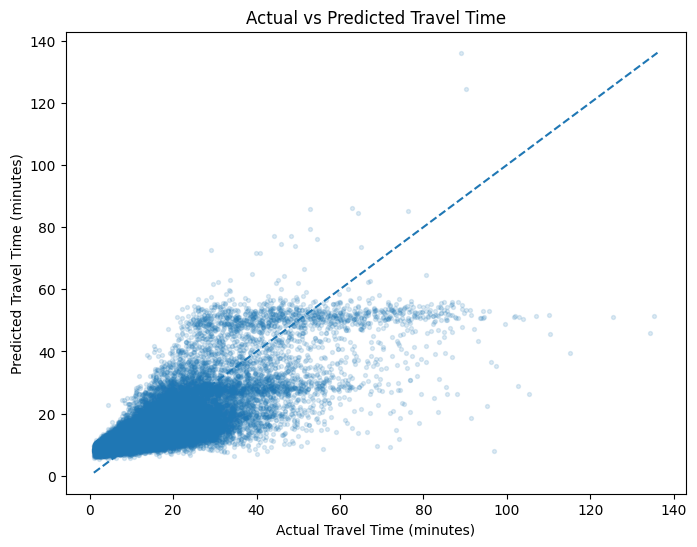

In [ ]:
# Step 36 — Plot actual travel time against the model's predicted travel time
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.15,
    s=8
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle='--'
)

plt.xlabel('Actual Travel Time (minutes)')
plt.ylabel('Predicted Travel Time (minutes)')
plt.title('Actual vs Predicted Travel Time')

plt.show()

In [ ]:
# Step 37 — Calculate the average travel time for each departure hour
hourly_mean = (
    train_df
    .groupby('hour')['travel_time_min']
    .mean()
    .reset_index()
)

print(hourly_mean)

    hour  travel_time_min
0      0        13.133738
1      1        12.667567
2      2        11.761898
3      3        11.817837
4      4        12.094630
5      5        12.067297
6      6        11.084106
7      7        12.659451
8      8        14.026559
9      9        14.029773
10    10        13.933227
11    11        14.352911
12    12        14.531068
13    13        14.775079
14    14        15.531619
15    15        15.644194
16    16        15.826645
17    17        15.244441
18    18        14.177684
19    19        13.302011
20    20        12.892971
21    21        12.934857
22    22        13.234826
23    23        13.715405


In [ ]:
# Step 38 — Fit polynomial curves of different degrees to the hourly mean travel time
degrees = [1, 2, 3, 4, 5]

polynomial_models = {}

x_hour = hourly_mean['hour'].values
y_hour = hourly_mean['travel_time_min'].values

for degree in degrees:
    coefficients = np.polyfit(x_hour, y_hour, degree)
    polynomial_models[degree] = np.poly1d(coefficients)

print("Polynomial models created for degrees 1 to 5.")

Polynomial models created for degrees 1 to 5.


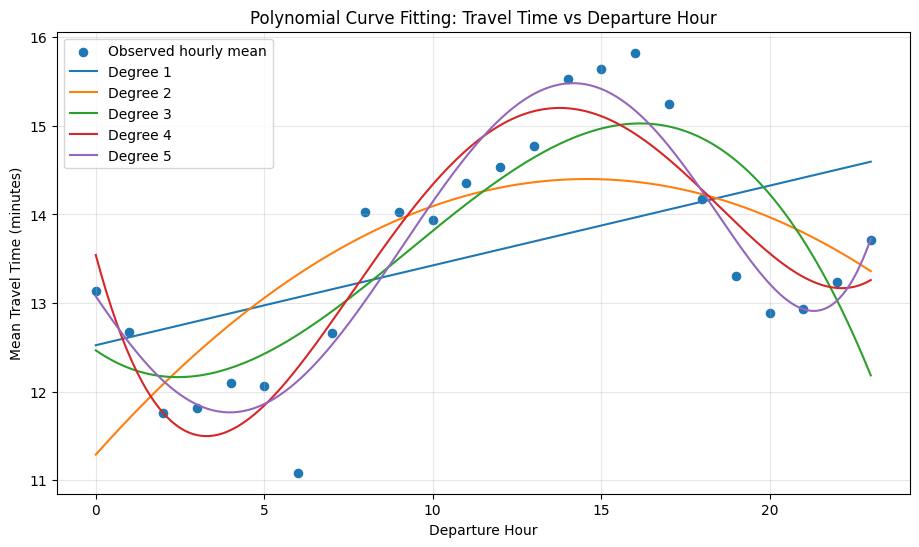

In [ ]:
# Step 39 — Compare polynomial degrees to observe underfitting and possible overfitting
x_smooth = np.linspace(0, 23, 300)

plt.figure(figsize=(11, 6))

plt.scatter(
    x_hour,
    y_hour,
    s=35,
    label='Observed hourly mean'
)

for degree in degrees:
    plt.plot(
        x_smooth,
        polynomial_models[degree](x_smooth),
        label=f'Degree {degree}'
    )

plt.xlabel('Departure Hour')
plt.ylabel('Mean Travel Time (minutes)')
plt.title('Polynomial Curve Fitting: Travel Time vs Departure Hour')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Step 40 — Select the polynomial degree using error on the unseen test period
test_hourly_mean = (
    test_df
    .groupby('hour')['travel_time_min']
    .mean()
    .reset_index()
)

validation_errors = {}

for degree in degrees:
    model = np.poly1d(
        np.polyfit(
            x_hour,
            y_hour,
            degree
        )
    )

    predictions = model(test_hourly_mean['hour'].values)

    mse = np.mean(
        (test_hourly_mean['travel_time_min'].values - predictions) ** 2
    )

    validation_errors[degree] = mse

print("Polynomial validation MSE:")
for degree, mse in validation_errors.items():
    print(f"Degree {degree}: {mse:.4f}")

best_degree = min(validation_errors, key=validation_errors.get)

print(f"\nSelected polynomial degree: {best_degree}")

Polynomial validation MSE:
Degree 1: 3.8639
Degree 2: 2.9619
Degree 3: 2.2617
Degree 4: 1.7778
Degree 5: 1.6049

Selected polynomial degree: 5


In [ ]:
# Step 41 — Calculate the observed 90th-percentile travel time
q90_empirical = project_df['travel_time_min'].quantile(0.90)
print(f"Empirical 90th percentile: {q90_empirical:.2f} minutes")

Empirical 90th percentile: 27.18 minutes


In [ ]:
# Step 42 — Calculate mean and standard deviation for the probability model
mu = train_df['travel_time_min'].mean()
sigma = train_df['travel_time_min'].std()
print(f"Mean (mu): {mu:.2f} minutes")
print(f"Standard deviation (sigma): {sigma:.2f} minutes")

Mean (mu): 13.87 minutes
Standard deviation (sigma): 10.67 minutes


In [ ]:
# Step 43 — Calculate the 90th percentile assuming a normal distribution
q90_normal = mu + 1.282 * sigma
print(f"Gaussian 90th percentile: {q90_normal:.2f} minutes")

Gaussian 90th percentile: 27.56 minutes


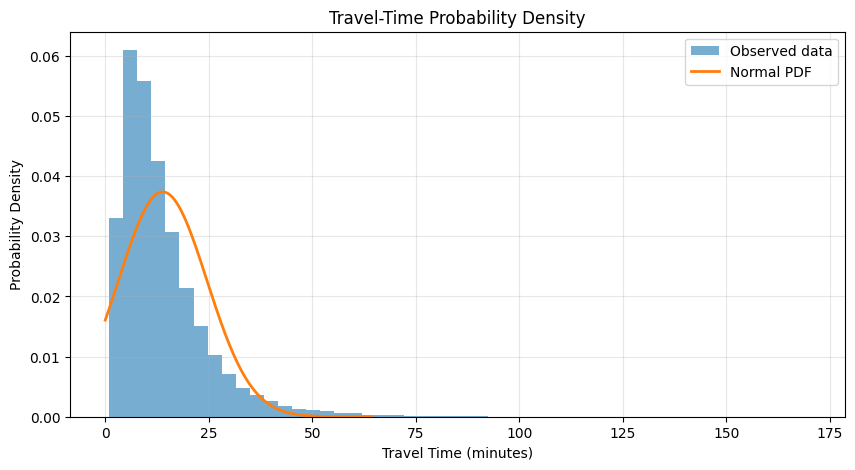

In [ ]:
# Step 44 — Plot the observed travel-time density and normal probability density
from scipy.stats import norm

x_pdf = np.linspace(0, project_df['travel_time_min'].quantile(0.995), 500)
pdf_values = norm.pdf(x_pdf, mu, sigma)

plt.figure(figsize=(10, 5))
plt.hist(train_df['travel_time_min'], bins=50, density=True, alpha=0.6, label='Observed data')
plt.plot(x_pdf, pdf_values, linewidth=2, label='Normal PDF')
plt.xlabel('Travel Time (minutes)')
plt.ylabel('Probability Density')
plt.title('Travel-Time Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Step 45 — Calculate the empirical expectation (average) of travel time
expectation_time = project_df['travel_time_min'].mean()

print(f"E[T] = {expectation_time:.2f} minutes")

E[T] = 14.07 minutes


In [ ]:
# Step 46 — Calculate conditional expectation of travel time for rainy and dry trips
expected_rain = project_df.loc[
    project_df['is_rain'] == 1,
    'travel_time_min'
].mean()

expected_dry = project_df.loc[
    project_df['is_rain'] == 0,
    'travel_time_min'
].mean()

print(f"E[T | Rain] = {expected_rain:.2f} minutes")
print(f"E[T | No Rain] = {expected_dry:.2f} minutes")

E[T | Rain] = 13.89 minutes
E[T | No Rain] = 14.16 minutes


In [ ]:
# Step 47 — Compare rain probability across weekdays to investigate independence
rain_by_weekday = pd.crosstab(
    project_df['weekday'],
    project_df['is_rain'],
    normalize='index'
)

rain_by_weekday.columns = ['No Rain Probability', 'Rain Probability']

print(rain_by_weekday.round(4))

           No Rain Probability  Rain Probability
weekday                                         
Friday                  0.5691            0.4309
Monday                  0.4910            0.5090
Saturday                0.7443            0.2557
Sunday                  0.6377            0.3623
Thursday                0.8833            0.1167
Tuesday                 0.7253            0.2747
Wednesday               0.6844            0.3156


In [ ]:
# Step 48 — Compare long-trip probabilities with and without rain while keeping peak status fixed
for peak_value in [0, 1]:

    subset_peak = project_df[
        project_df['is_peak_hour'] == peak_value
    ]

    p_long_given_peak = subset_peak['is_long_trip'].mean()

    subset_rain_peak = subset_peak[
        subset_peak['is_rain'] == 1
    ]

    p_long_given_rain_peak = subset_rain_peak['is_long_trip'].mean()

    print(
        f"Peak={peak_value}: "
        f"P(Long | Peak) = {p_long_given_peak:.4f}, "
        f"P(Long | Rain, Peak) = {p_long_given_rain_peak:.4f}"
    )

Peak=0: P(Long | Peak) = 0.2486, P(Long | Rain, Peak) = 0.2439
Peak=1: P(Long | Peak) = 0.2525, P(Long | Rain, Peak) = 0.2442


In [ ]:
# Step 49 — Calculate covariance between travel time, distance, temperature, and precipitation
analysis_columns = [
    'travel_time_min',
    'distance_km',
    'avg_temp',
    'precipitation'
]

covariance_matrix = project_df[analysis_columns].cov()

print("Covariance Matrix:")
print(covariance_matrix.round(3))

Covariance Matrix:
                 travel_time_min  distance_km  avg_temp  precipitation
travel_time_min          119.351       33.334     9.319         -0.036
distance_km               33.334       15.597     1.213         -0.002
avg_temp                   9.319        1.213   244.673          0.081
precipitation             -0.036       -0.002     0.081          0.062


In [ ]:
# Step 50 — Create a summary table containing the main Unit 1 statistical results
summary = pd.DataFrame({
    'Measure': [
        'Mean Travel Time',
        'Variance',
        'Standard Deviation',
        'Median',
        '75th Percentile',
        '90th Percentile',
        'Gaussian 90th Percentile',
        'Expected Time | Rain',
        'Expected Time | No Rain'
    ],
    'Value': [
        project_df['travel_time_min'].mean(),
        project_df['travel_time_min'].var(),
        project_df['travel_time_min'].std(),
        project_df['travel_time_min'].quantile(0.50),
        project_df['travel_time_min'].quantile(0.75),
        project_df['travel_time_min'].quantile(0.90),
        q90_normal,
        expected_rain,
        expected_dry
    ]
})

print(summary.round(2))

                    Measure   Value
0          Mean Travel Time   14.07
1                  Variance  119.35
2        Standard Deviation   10.92
3                    Median   11.15
4           75th Percentile   17.98
5           90th Percentile   27.18
6  Gaussian 90th Percentile   27.56
7      Expected Time | Rain   13.89
8   Expected Time | No Rain   14.16


In [ ]:
# Step 51 — Select numerical variables used by K-Means to discover hidden trip patterns
cluster_features = [
    'hour',
    'weekday_num',
    'passenger_count',
    'distance_km',
    'avg_temp',
    'precipitation',
    'travel_time_min'
]

cluster_data = project_df[cluster_features].copy()

print("Clustering variables:")
print(cluster_features)
print("\nShape:", cluster_data.shape)

Clustering variables:
['hour', 'weekday_num', 'passenger_count', 'distance_km', 'avg_temp', 'precipitation', 'travel_time_min']

Shape: (200000, 7)


In [ ]:
# Step 52 — Standardize clustering variables so large-scale features do not dominate K-Means
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

print("Standardized data shape:", cluster_scaled.shape)

Standardized data shape: (200000, 7)


In [ ]:
# Step 53 — Select a reproducible sample to make K-Means faster while retaining enough observations
cluster_sample = project_df.sample(
    n=min(50000, len(project_df)),
    random_state=42
).copy()

print("Clustering sample size:", len(cluster_sample))

Clustering sample size: 50000


In [ ]:
# Step 54 — Standardize the selected clustering sample before applying K-Means
cluster_sample_data = cluster_sample[cluster_features]

cluster_sample_scaled = scaler.fit_transform(
    cluster_sample_data
)

print("Prepared clustering matrix:", cluster_sample_scaled.shape)

Prepared clustering matrix: (50000, 7)


In [ ]:
# Step 55 — Calculate K-Means inertia for different cluster counts to help choose K
from sklearn.cluster import KMeans

inertias = []

k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_sample_scaled)

    inertias.append(kmeans.inertia_)

for k, inertia in zip(k_values, inertias):
    print(f"K={k}: Inertia={inertia:.2f}")

K=2: Inertia=292686.02
K=3: Inertia=254775.28
K=4: Inertia=223740.65
K=5: Inertia=194827.00
K=6: Inertia=173892.24


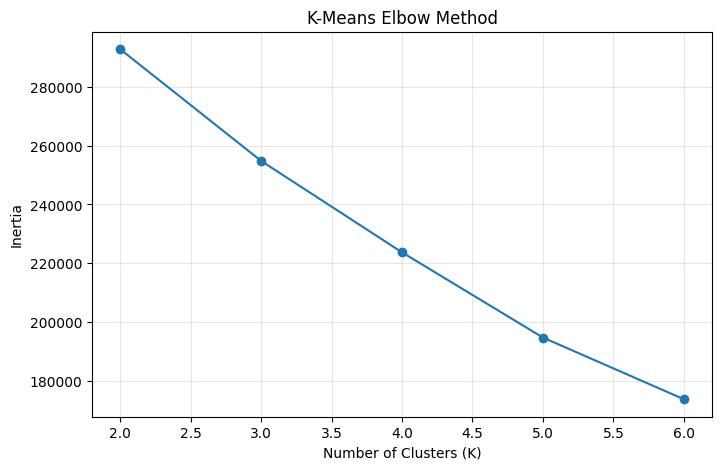

In [ ]:
# Step 56 — Plot the elbow curve to visualize a suitable number of clusters
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')

plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Step 57 — Train the final K-Means model with four initially selected trip clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    cluster_sample_scaled
)

cluster_sample['cluster'] = cluster_labels

print("K-Means clustering completed.")
print(cluster_sample['cluster'].value_counts().sort_index())

K-Means clustering completed.
cluster
0     4646
1    20830
2    19503
3     5021
Name: count, dtype: int64


In [ ]:
# Step 58 — Calculate the average characteristics of each discovered trip cluster
cluster_summary = (
    cluster_sample
    .groupby('cluster')[cluster_features]
    .mean()
    .round(2)
)

print(cluster_summary)

          hour  weekday_num  passenger_count  distance_km  avg_temp  \
cluster                                                               
0        13.48         2.96             1.53        13.25     53.68   
1        12.38         4.68             1.27         2.52     50.75   
2        14.92         1.34             1.23         2.42     52.21   
3        13.74         3.17             5.12         2.74     51.63   

         precipitation  travel_time_min  
cluster                                  
0                 0.08            38.40  
1                 0.07            11.29  
2                 0.10            11.83  
3                 0.09            12.43  


In [ ]:
# Step 59 — Measure how clearly separated the discovered clusters are using silhouette score
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    cluster_sample_scaled,
    cluster_labels
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.1805


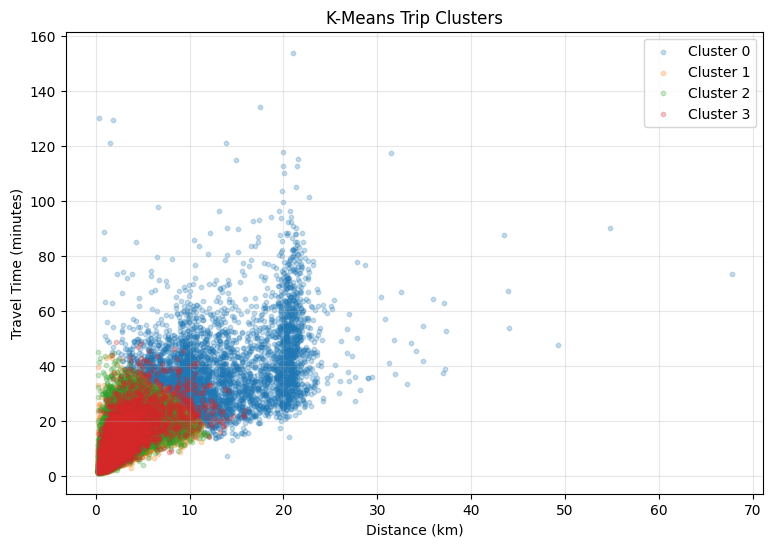

In [ ]:
# Step 60 — Visualize the discovered trip clusters using distance and travel time
plt.figure(figsize=(9, 6))

for cluster in sorted(cluster_sample['cluster'].unique()):

    subset = cluster_sample[
        cluster_sample['cluster'] == cluster
    ]

    plt.scatter(
        subset['distance_km'],
        subset['travel_time_min'],
        s=10,
        alpha=0.25,
        label=f'Cluster {cluster}'
    )

plt.xlabel('Distance (km)')
plt.ylabel('Travel Time (minutes)')
plt.title('K-Means Trip Clusters')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Step 61 — Remove unrealistic passenger counts so outliers do not distort the clustering
cluster_final = project_df[
    project_df['passenger_count'].between(1, 6)
].copy()

print("Rows available for clustering:", len(cluster_final))
print("Passenger counts:")
print(cluster_final['passenger_count'].value_counts().sort_index())

Rows available for clustering: 200000
Passenger counts:
passenger_count
1    141720
2     28773
3      8325
4      3825
5     10705
6      6652
Name: count, dtype: int64


In [ ]:
# Step 62 — Represent hour cyclically so 23:00 and 00:00 are treated as nearby times
cluster_final['hour_sin'] = np.sin(
    2 * np.pi * cluster_final['hour'] / 24
)

cluster_final['hour_cos'] = np.cos(
    2 * np.pi * cluster_final['hour'] / 24
)

print(
    cluster_final[
        ['hour', 'hour_sin', 'hour_cos']
    ].head()
)

   hour  hour_sin  hour_cos
0     0       0.0       1.0
1     0       0.0       1.0
2     0       0.0       1.0
3     0       0.0       1.0
4     0       0.0       1.0


In [ ]:
# Step 63 — Select only trip-condition variables and exclude the travel-time target
cluster_features_final = [
    'hour_sin',
    'hour_cos',
    'weekday_num',
    'distance_km',
    'passenger_count',
    'avg_temp',
    'precipitation',
    'is_rain',
    'is_snow'
]

print("Final clustering features:")
print(cluster_features_final)

Final clustering features:
['hour_sin', 'hour_cos', 'weekday_num', 'distance_km', 'passenger_count', 'avg_temp', 'precipitation', 'is_rain', 'is_snow']


In [ ]:
# Step 64 — Standardize the final clustering variables before applying K-Means
cluster_scaler = StandardScaler()

cluster_final_scaled = cluster_scaler.fit_transform(
    cluster_final[cluster_features_final]
)

print("Standardized matrix shape:", cluster_final_scaled.shape)

Standardized matrix shape: (200000, 9)


In [ ]:
# Step 65 — Create a reproducible sample for efficient K-Means computation
cluster_work = cluster_final.sample(
    n=min(50000, len(cluster_final)),
    random_state=42
).copy()

cluster_work_scaled = cluster_scaler.transform(
    cluster_work[cluster_features_final]
)

print("Final K-Means sample:", len(cluster_work))

Final K-Means sample: 50000


In [ ]:
# Step 66 — Calculate K-Means inertia for several cluster counts
inertias_final = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(cluster_work_scaled)
    inertias_final.append(model.inertia_)

for k, inertia in zip(range(2, 7), inertias_final):
    print(f"K={k}: Inertia={inertia:.2f}")

K=2: Inertia=381176.24
K=3: Inertia=333274.94
K=4: Inertia=299036.74
K=5: Inertia=269327.24
K=6: Inertia=243250.78


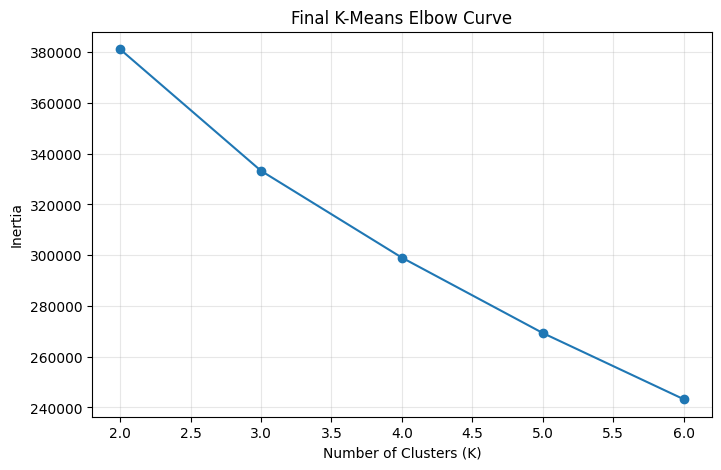

In [ ]:
# Step 67 — Visualize the final elbow curve to help select the number of clusters
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 7),
    inertias_final,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Final K-Means Elbow Curve')
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Step 68 — Build the final unsupervised K-Means model using four trip-condition clusters
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_work['cluster'] = final_kmeans.fit_predict(
    cluster_work_scaled
)

print("Final K-Means model completed.")
print(cluster_work['cluster'].value_counts().sort_index())

Final K-Means model completed.
cluster
0    14205
1    18415
2    15452
3     1928
Name: count, dtype: int64


In [ ]:
# Step 69 — Summarize the real-world characteristics of each discovered trip cluster
cluster_description = (
    cluster_work
    .groupby('cluster')[
        [
            'hour',
            'weekday_num',
            'distance_km',
            'passenger_count',
            'avg_temp',
            'precipitation',
            'is_rain',
            'is_snow'
        ]
    ]
    .mean()
    .round(2)
)

print(cluster_description)

          hour  weekday_num  distance_km  passenger_count  avg_temp  \
cluster                                                               
0        13.52         2.93         3.48             1.66     54.58   
1        16.25         3.26         3.73             1.69     51.39   
2        10.56         2.99         3.26             1.63     51.67   
3        13.51         2.79         3.46             1.69     33.13   

         precipitation  is_rain  is_snow  
cluster                                   
0                 0.27      1.0      0.0  
1                 0.00      0.0      0.0  
2                 0.00      0.0      0.0  
3                 0.24      1.0      1.0  


In [ ]:
# Step 70 — Evaluate how well the final trip-condition clusters are separated
final_silhouette = silhouette_score(
    cluster_work_scaled,
    cluster_work['cluster']
)

print(f"Final Silhouette Score: {final_silhouette:.4f}")

Final Silhouette Score: 0.1674


In [ ]:
# Step 71 — Calculate prediction residuals so we can measure the uncertainty of the travel-time model
test_results = test_df.copy()

test_results['predicted_time'] = y_pred
test_results['residual'] = (
    test_results['travel_time_min'] - test_results['predicted_time']
)

print(test_results[['travel_time_min', 'predicted_time', 'residual']].head())

        travel_time_min  predicted_time  residual
160000        14.283333       15.707758 -1.424425
160001        10.483333       12.019729 -1.536396
160002         6.216667        9.176387 -2.959720
160003         7.116667       12.142535 -5.025868
160004        12.550000       12.553393 -0.003393


In [ ]:
# Step 72 — Calculate residual standard deviation and the 90th-percentile prediction error
residual_std = test_results['residual'].std()
residual_q90 = test_results['residual'].quantile(0.90)

print(f"Residual standard deviation: {residual_std:.2f} minutes")
print(f"90th-percentile residual: {residual_q90:.2f} minutes")

Residual standard deviation: 7.47 minutes
90th-percentile residual: 8.59 minutes


In [ ]:
# Step 73 — Create a reusable function that predicts travel time for a given trip condition
def predict_travel_time(
    hour,
    weekday_num,
    distance_km,
    passenger_count,
    avg_temp,
    precipitation,
    is_rain
):
    input_data = pd.DataFrame([{
        'hour': hour,
        'weekday_num': weekday_num,
        'is_weekend': int(weekday_num >= 5),
        'is_peak_hour': int(
            (7 <= hour <= 9) or (16 <= hour <= 19)
        ),
        'passenger_count': passenger_count,
        'distance_km': distance_km,
        'avg_temp': avg_temp,
        'precipitation': precipitation,
        'is_rain': is_rain,
        'snowfall': 0
    }])

    prediction = linear_model.predict(input_data[features])[0]

    return max(prediction, 1.0)

print("Prediction function created.")

Prediction function created.


In [ ]:
# Step 74A — Save the trained model, features, and uncertainty information to Google Drive

import joblib
import os

checkpoint = {
    "model": linear_model,
    "features": features,
    "residual_q90": residual_q90,
    "residual_std": residual_std,
    "long_trip_threshold": long_trip_threshold,
    "best_degree": best_degree,
    "polynomial_coefficients": polynomial_models[best_degree].c
}

checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "leave_by_model_checkpoint.joblib"
)

joblib.dump(checkpoint, checkpoint_path)

print("Model checkpoint saved successfully!")
print("Location:", checkpoint_path)

Model checkpoint saved successfully!
Location: /content/drive/MyDrive/Leave_By_Project/leave_by_model_checkpoint.joblib


In [ ]:
# Step 74 — Add the empirical 90th-percentile uncertainty margin to obtain a safer travel-time estimate
def predict_q90_travel_time(
    hour,
    weekday_num,
    distance_km,
    passenger_count,
    avg_temp,
    precipitation,
    is_rain
):
    predicted = predict_travel_time(
        hour,
        weekday_num,
        distance_km,
        passenger_count,
        avg_temp,
        precipitation,
        is_rain
    )

    q90_prediction = predicted + max(residual_q90, 0)

    return max(q90_prediction, predicted)

print("90th-percentile prediction function created.")

90th-percentile prediction function created.


In [ ]:
# Step 75 — Find the latest departure time that keeps the estimated 90th-percentile arrival before the deadline
from datetime import datetime, timedelta

def leave_by_advisor(
    arrival_time,
    weekday_num,
    distance_km,
    passenger_count,
    avg_temp,
    precipitation,
    is_rain
):
    deadline = datetime.strptime(arrival_time, "%H:%M")

    possible_departures = []

    # Check every 10 minutes during the day
    for hour in range(24):
        for minute in range(0, 60, 10):

            departure = datetime.strptime(
                f"{hour:02d}:{minute:02d}",
                "%H:%M"
            )

            q90_time = predict_q90_travel_time(
                hour,
                weekday_num,
                distance_km,
                passenger_count,
                avg_temp,
                precipitation,
                is_rain
            )

            estimated_arrival = departure + timedelta(
                minutes=q90_time
            )

            if estimated_arrival <= deadline:
                possible_departures.append(
                    (departure, q90_time, estimated_arrival)
                )

    if not possible_departures:
        return None

    return possible_departures[-1]

print("Leave-By advisor created.")

Leave-By advisor created.


In [ ]:
# Step 76 — Test the Leave-By advisor with an example rainy Monday trip
result = leave_by_advisor(
    arrival_time="09:00",
    weekday_num=0,
    distance_km=5,
    passenger_count=1,
    avg_temp=45,
    precipitation=0.3,
    is_rain=1
)

print("Advisor result:")

if result is None:
    print("No feasible departure time found.")
else:
    departure, q90_time, estimated_arrival = result

    print("Recommended latest departure:",
          departure.strftime("%H:%M"))
    print(f"90th-percentile travel time: {q90_time:.2f} minutes")
    print("Estimated arrival:",
          estimated_arrival.strftime("%H:%M"))

Advisor result:
Recommended latest departure: 08:30
90th-percentile travel time: 25.78 minutes
Estimated arrival: 08:55


In [ ]:
# Step 77 — Compare the recommended departure under dry conditions
result_dry = leave_by_advisor(
    arrival_time="09:00",
    weekday_num=0,
    distance_km=5,
    passenger_count=1,
    avg_temp=45,
    precipitation=0,
    is_rain=0
)

if result_dry is None:
    print("No feasible departure time found.")
else:
    departure, q90_time, estimated_arrival = result_dry

    print("Dry condition:")
    print("Recommended departure:", departure.strftime("%H:%M"))
    print(f"90th-percentile travel time: {q90_time:.2f} minutes")
    print("Estimated arrival:", estimated_arrival.strftime("%H:%M"))

Dry condition:
Recommended departure: 08:30
90th-percentile travel time: 26.10 minutes
Estimated arrival: 08:56


In [ ]:
# Step 78 — Create a simple interactive interface for entering a trip and receiving a Leave-By recommendation
print("=== LEAVE-BY TRAVEL ADVISOR ===")

arrival_input = input("Required arrival time (HH:MM): ")
weekday_input = int(input("Weekday number (Monday=0 ... Sunday=6): "))
distance_input = float(input("Distance (km): "))
passenger_input = int(input("Passengers: "))
temperature_input = float(input("Average temperature (°F): "))
rain_input = int(input("Rain? (1=Yes, 0=No): "))
precipitation_input = float(input("Precipitation: "))

advisor_result = leave_by_advisor(
    arrival_input,
    weekday_input,
    distance_input,
    passenger_input,
    temperature_input,
    precipitation_input,
    rain_input
)

print("\n=== RESULT ===")

if advisor_result is None:
    print("No feasible departure time found.")
else:
    departure, q90_time, estimated_arrival = advisor_result

    print("Latest recommended departure:",
          departure.strftime("%H:%M"))
    print(f"Estimated 90th-percentile travel time: {q90_time:.2f} minutes")
    print("Estimated arrival:",
          estimated_arrival.strftime("%H:%M"))

=== LEAVE-BY TRAVEL ADVISOR ===
Required arrival time (HH:MM): 16:00
Weekday number (Monday=0 ... Sunday=6): 2
Distance (km): 4
Passengers: 1
Average temperature (°F): 45
Rain? (1=Yes, 0=No): 0
Precipitation: 0

=== RESULT ===
Latest recommended departure: 15:30
Estimated 90th-percentile travel time: 23.71 minutes
Estimated arrival: 15:53


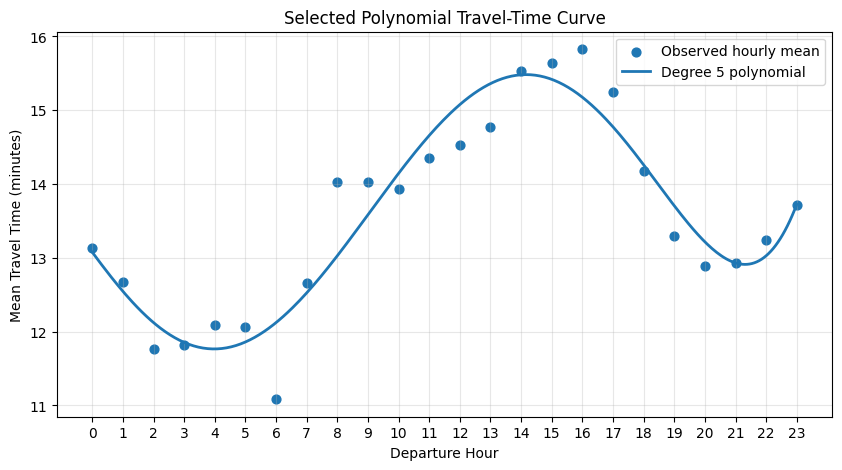

In [ ]:
# Step 79 — Display the selected polynomial mean travel-time curve used to understand time-dependent travel behavior
best_polynomial = polynomial_models[best_degree]

plt.figure(figsize=(10, 5))

plt.scatter(
    hourly_mean['hour'],
    hourly_mean['travel_time_min'],
    s=40,
    label='Observed hourly mean'
)

plt.plot(
    x_smooth,
    best_polynomial(x_smooth),
    linewidth=2,
    label=f'Degree {best_degree} polynomial'
)

plt.xlabel('Departure Hour')
plt.ylabel('Mean Travel Time (minutes)')
plt.title('Selected Polynomial Travel-Time Curve')
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Step 80 — Summarize the mathematical pipeline connecting prediction, uncertainty, and the Leave-By decision
print("=== LEAVE-BY MODEL PIPELINE ===")
print("1. Supervised model predicts expected travel time.")
print("2. Residuals measure prediction uncertainty.")
print("3. The 90th-percentile residual provides a safety margin.")
print("4. Candidate departure times are tested.")
print("5. The latest time satisfying the arrival deadline is recommended.")

=== LEAVE-BY MODEL PIPELINE ===
1. Supervised model predicts expected travel time.
2. Residuals measure prediction uncertainty.
3. The 90th-percentile residual provides a safety margin.
4. Candidate departure times are tested.
5. The latest time satisfying the arrival deadline is recommended.


In [ ]:
# Step 81 — Compare a simple fixed 45-minute rule with the machine-learning prediction
simple_rule_time = 45

print(f"Simple rule travel time: {simple_rule_time} minutes")
print(f"ML predicted travel time: {predict_travel_time(8, 0, 5, 1, 45, 0.3, 1):.2f} minutes")
print(f"ML 90th-percentile estimate: {predict_q90_travel_time(8, 0, 5, 1, 45, 0.3, 1):.2f} minutes")

Simple rule travel time: 45 minutes
ML predicted travel time: 17.19 minutes
ML 90th-percentile estimate: 25.78 minutes


In [ ]:
# Step 82 — Evaluate how often historical trips would meet a simulated 30-minute travel-time deadline
evaluation_df = test_df.copy()

evaluation_df['predicted_time'] = y_pred
evaluation_df['predicted_q90'] = y_pred + max(residual_q90, 0)

evaluation_df['actual_on_time'] = (
    evaluation_df['travel_time_min'] <= 30
).astype(int)

evaluation_df['predicted_on_time'] = (
    evaluation_df['predicted_time'] <= 30
).astype(int)

accuracy = (
    evaluation_df['actual_on_time'] ==
    evaluation_df['predicted_on_time']
).mean()

print(f"On-time classification accuracy: {accuracy:.4f}")

On-time classification accuracy: 0.9341


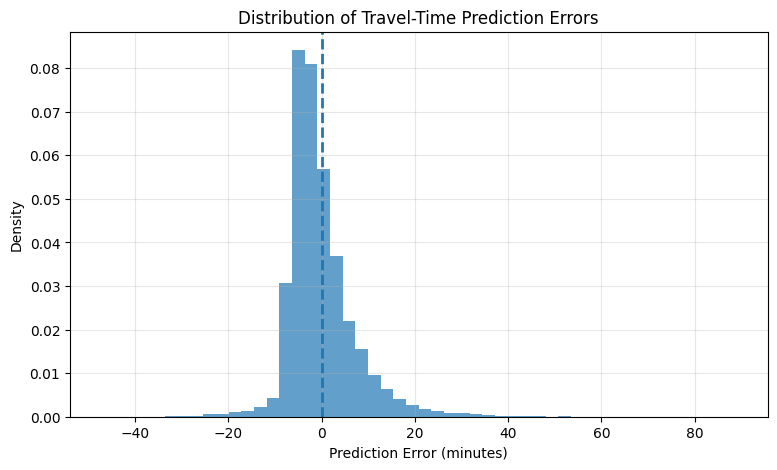

In [ ]:
# Step 83 — Visualize the distribution of prediction errors
plt.figure(figsize=(9, 5))

plt.hist(
    test_results['residual'],
    bins=50,
    density=True,
    alpha=0.7
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=2
)

plt.xlabel('Prediction Error (minutes)')
plt.ylabel('Density')
plt.title('Distribution of Travel-Time Prediction Errors')

plt.grid(alpha=0.3)
plt.show()

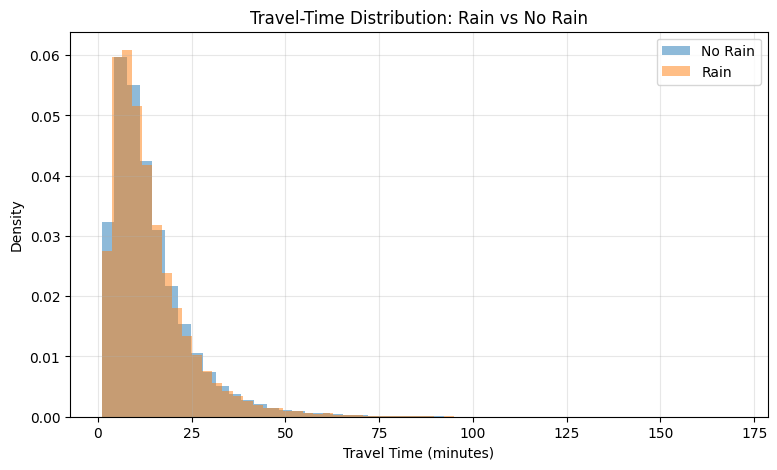

In [ ]:
# Step 84 — Compare the observed travel-time distributions under rainy and dry conditions
rain_times = project_df.loc[
    project_df['is_rain'] == 1,
    'travel_time_min'
]

dry_times = project_df.loc[
    project_df['is_rain'] == 0,
    'travel_time_min'
]

plt.figure(figsize=(9, 5))

plt.hist(
    dry_times,
    bins=50,
    density=True,
    alpha=0.5,
    label='No Rain'
)

plt.hist(
    rain_times,
    bins=50,
    density=True,
    alpha=0.5,
    label='Rain'
)

plt.xlabel('Travel Time (minutes)')
plt.ylabel('Density')
plt.title('Travel-Time Distribution: Rain vs No Rain')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Step 85 — Display correlations between the main numerical variables
correlation_matrix = project_df[
    [
        'travel_time_min',
        'distance_km',
        'avg_temp',
        'precipitation',
        'passenger_count'
    ]
].corr()

print(correlation_matrix.round(3))

                 travel_time_min  distance_km  avg_temp  precipitation  \
travel_time_min            1.000        0.773     0.055         -0.013   
distance_km                0.773        1.000     0.020         -0.002   
avg_temp                   0.055        0.020     1.000          0.021   
precipitation             -0.013       -0.002     0.021          1.000   
passenger_count            0.011        0.008    -0.003          0.002   

                 passenger_count  
travel_time_min            0.011  
distance_km                0.008  
avg_temp                  -0.003  
precipitation              0.002  
passenger_count            1.000  


In [ ]:
# Step 86 — Create a final table summarizing the machine-learning and polynomial-model results
model_results = pd.DataFrame({
    'Model / Measure': [
        'Linear Regression',
        f'Polynomial Degree {best_degree}',
        'Empirical 90th Percentile',
        'Gaussian 90th Percentile'
    ],
    'Result': [
        f'MAE = {mae:.2f} min, RMSE = {rmse:.2f} min',
        f'Validation MSE = {validation_errors[best_degree]:.4f}',
        f'{q90_empirical:.2f} min',
        f'{q90_normal:.2f} min'
    ]
})

print(model_results)

             Model / Measure                           Result
0          Linear Regression  MAE = 5.24 min, RMSE = 7.47 min
1        Polynomial Degree 5          Validation MSE = 1.6049
2  Empirical 90th Percentile                        27.18 min
3   Gaussian 90th Percentile                        27.56 min


In [ ]:
# Step 87 — Create a final table summarizing the probability and Bayes calculations
probability_summary = pd.DataFrame({
    'Quantity': [
        'P(Rain)',
        'P(Long Trip)',
        'P(Long Trip | Rain)',
        'P(Rain | Long Trip)',
        'Bayes P(Rain | Long Trip)'
    ],
    'Value': [
        project_df['is_rain'].mean(),
        project_df['is_long_trip'].mean(),
        p_long_given_rain,
        p_rain_given_long,
        bayes_value
    ]
})

print(probability_summary.round(4))

                    Quantity   Value
0                    P(Rain)  0.3204
1               P(Long Trip)  0.2500
2        P(Long Trip | Rain)  0.2440
3        P(Rain | Long Trip)  0.3127
4  Bayes P(Rain | Long Trip)  0.3127


In [ ]:
# Step 88 — Save the cleaned project dataset so the complete analysis can be reproduced later
project_df.to_csv(
    '/content/Leave_By_Final_Dataset.csv',
    index=False
)

print("Saved: Leave_By_Final_Dataset.csv")

Saved: Leave_By_Final_Dataset.csv


In [ ]:
# Step 89 — Save the important project results and methodology for use in the review
project_summary = f"""
LEAVE-BY: UNCERTAINTY-AWARE TRAVEL DEPARTURE ADVISOR

Dataset:
NYC Taxi Trip Duration + NYC weather

Working records:
{len(project_df)}

Machine Learning:
Linear Regression
MAE = {mae:.2f} minutes
RMSE = {rmse:.2f} minutes

Polynomial Curve:
Selected degree = {best_degree}
Validation MSE = {validation_errors[best_degree]:.4f}

Statistics:
Mean travel time = {project_df['travel_time_min'].mean():.2f} min
Variance = {project_df['travel_time_min'].var():.2f}
90th percentile = {q90_empirical:.2f} min

Probability:
P(Long Trip | Rain) = {p_long_given_rain:.4f}
P(Rain | Long Trip) = {p_rain_given_long:.4f}

Unsupervised Learning:
K-Means clustering

Main output:
Latest recommended departure time based on predicted travel
time and a 90th-percentile uncertainty margin.
"""

with open('/content/Leave_By_Project_Summary.txt', 'w') as f:
    f.write(project_summary)

print(project_summary)


LEAVE-BY: UNCERTAINTY-AWARE TRAVEL DEPARTURE ADVISOR

Dataset:
NYC Taxi Trip Duration + NYC weather

Working records:
200000

Machine Learning:
Linear Regression
MAE = 5.24 minutes
RMSE = 7.47 minutes

Polynomial Curve:
Selected degree = 5
Validation MSE = 1.6049

Statistics:
Mean travel time = 14.07 min
Variance = 119.35
90th percentile = 27.18 min

Probability:
P(Long Trip | Rain) = 0.2440
P(Rain | Long Trip) = 0.3127

Unsupervised Learning:
K-Means clustering

Main output:
Latest recommended departure time based on predicted travel
time and a 90th-percentile uncertainty margin.



In [ ]:
# Step 90 — Verify that the main project components have been successfully completed
checks = {
    'Dataset prepared': len(project_df) > 0,
    'Weather merged': project_df['avg_temp'].notna().all(),
    'Supervised ML': len(y_pred) == len(y_test),
    'Polynomial fitting': best_degree in degrees,
    'Bayes calculation': abs(p_rain_given_long - bayes_value) < 1e-6,
    'K-Means': 'cluster' in cluster_work.columns,
    'Leave-By advisor': result is not None
}

print("=== FINAL PROJECT CHECK ===")

for item, status in checks.items():
    print(f"{item}: {'PASS' if status else 'CHECK'}")

=== FINAL PROJECT CHECK ===
Dataset prepared: PASS
Weather merged: PASS
Supervised ML: PASS
Polynomial fitting: PASS
Bayes calculation: PASS
K-Means: PASS
Leave-By advisor: PASS


In [ ]:
# Step 91 — Calculate MAE, RMSE, and R² to evaluate the travel-time regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R²   : {r2:.4f}")

MAE  : 5.24 minutes
RMSE : 7.47 minutes
R²   : 0.6016


In [ ]:
# Step 92 — Convert travel time into a binary Long Trip/Normal Trip classification target
long_trip_threshold = train_df['travel_time_min'].quantile(0.75)

y_test_class = (
    y_test > long_trip_threshold
).astype(int)

y_pred_class = (
    y_pred > long_trip_threshold
).astype(int)

print(f"Long-trip threshold: {long_trip_threshold:.2f} minutes")

Long-trip threshold: 17.77 minutes


In [ ]:
# Step 93 — Evaluate the long-trip classification using precision, recall, and F1-score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8495
Precision: 0.8255
Recall   : 0.5850
F1 Score : 0.6848


Confusion Matrix:
[[27444  1382]
 [ 4637  6537]]


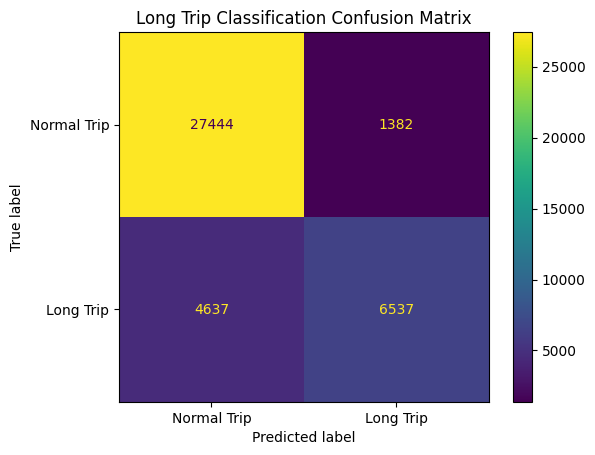

In [ ]:
# Step 94 — Create a confusion matrix to show how the Long Trip classifier performs
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_class, y_pred_class)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal Trip', 'Long Trip']
)

disp.plot()
plt.title('Long Trip Classification Confusion Matrix')
plt.grid(False)
plt.show()

In [ ]:
# Step 95 — Generate precision, recall, F1-score, and support for both classes
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_class,
        y_pred_class,
        target_names=['Normal Trip', 'Long Trip']
    )
)

              precision    recall  f1-score   support

 Normal Trip       0.86      0.95      0.90     28826
   Long Trip       0.83      0.59      0.68     11174

    accuracy                           0.85     40000
   macro avg       0.84      0.77      0.79     40000
weighted avg       0.85      0.85      0.84     40000



In [ ]:
# Step 96 — Compare the ML model with a simple fixed 45-minute travel-time rule
simple_predictions = np.full(
    len(y_test),
    45.0
)

simple_mae = mean_absolute_error(
    y_test,
    simple_predictions
)

simple_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        simple_predictions
    )
)

simple_r2 = r2_score(
    y_test,
    simple_predictions
)

print("Simple 45-minute rule:")
print(f"MAE  : {simple_mae:.2f} minutes")
print(f"RMSE : {simple_rmse:.2f} minutes")
print(f"R²   : {simple_r2:.4f}")

print("\nMachine Learning model:")
print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R²   : {r2:.4f}")

Simple 45-minute rule:
MAE  : 30.96 minutes
RMSE : 32.38 minutes
R²   : -6.4783

Machine Learning model:
MAE  : 5.24 minutes
RMSE : 7.47 minutes
R²   : 0.6016


In [ ]:
# Step 97 — Compare the latest departure recommendation under different weather conditions
scenarios = [
    ('Dry Monday', 0, 5, 1, 45, 0.0, 0),
    ('Rainy Monday', 0, 5, 1, 45, 0.3, 1),
    ('Dry Friday', 4, 5, 1, 45, 0.0, 0),
    ('Rainy Friday', 4, 5, 1, 45, 0.3, 1)
]

for name, weekday, distance, passengers, temp, precip, rain in scenarios:

    result = leave_by_advisor(
        arrival_time="09:00",
        weekday_num=weekday,
        distance_km=distance,
        passenger_count=passengers,
        avg_temp=temp,
        precipitation=precip,
        is_rain=rain
    )

    print(f"\n{name}")

    if result is None:
        print("No feasible departure found.")
    else:
        departure, q90_time, arrival = result

        print("Latest departure:", departure.strftime("%H:%M"))
        print(f"90th-percentile travel time: {q90_time:.2f} min")
        print("Estimated arrival:", arrival.strftime("%H:%M"))


Dry Monday
Latest departure: 08:30
90th-percentile travel time: 26.10 min
Estimated arrival: 08:56

Rainy Monday
Latest departure: 08:30
90th-percentile travel time: 25.78 min
Estimated arrival: 08:55

Dry Friday
Latest departure: 08:30
90th-percentile travel time: 27.00 min
Estimated arrival: 08:56

Rainy Friday
Latest departure: 08:30
90th-percentile travel time: 26.67 min
Estimated arrival: 08:56


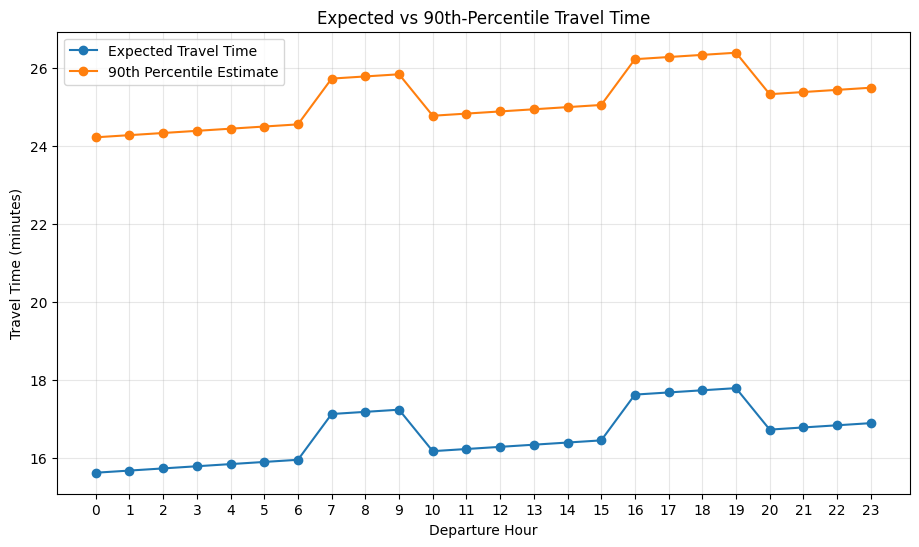

In [ ]:
# Step 98 — Visualize expected travel time versus the 90th-percentile safety estimate
hours_to_plot = np.arange(24)

expected_curve = np.array([
    predict_travel_time(
        hour=h,
        weekday_num=0,
        distance_km=5,
        passenger_count=1,
        avg_temp=45,
        precipitation=0.3,
        is_rain=1
    )
    for h in hours_to_plot
])

q90_curve = np.array([
    predict_q90_travel_time(
        hour=h,
        weekday_num=0,
        distance_km=5,
        passenger_count=1,
        avg_temp=45,
        precipitation=0.3,
        is_rain=1
    )
    for h in hours_to_plot
])

plt.figure(figsize=(11, 6))

plt.plot(
    hours_to_plot,
    expected_curve,
    marker='o',
    label='Expected Travel Time'
)

plt.plot(
    hours_to_plot,
    q90_curve,
    marker='o',
    label='90th Percentile Estimate'
)

plt.xlabel('Departure Hour')
plt.ylabel('Travel Time (minutes)')
plt.title('Expected vs 90th-Percentile Travel Time')
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Step 99 — Display the final statistics and evaluation metrics in one project summary
final_results = pd.DataFrame({
    'Metric': [
        'Dataset Size',
        'Mean Travel Time',
        'Standard Deviation',
        '90th Percentile',
        'Linear Regression MAE',
        'Linear Regression RMSE',
        'Linear Regression R²',
        'Long Trip Accuracy',
        'Long Trip Precision',
        'Long Trip Recall',
        'Long Trip F1',
        'K-Means Silhouette'
    ],
    'Value': [
        len(project_df),
        project_df['travel_time_min'].mean(),
        project_df['travel_time_min'].std(),
        project_df['travel_time_min'].quantile(0.90),
        mae,
        rmse,
        r2,
        accuracy,
        precision,
        recall,
        f1,
        final_silhouette
    ]
})

print(final_results.round(4))

                    Metric        Value
0             Dataset Size  200000.0000
1         Mean Travel Time      14.0717
2       Standard Deviation      10.9248
3          90th Percentile      27.1833
4    Linear Regression MAE       5.2362
5   Linear Regression RMSE       7.4727
6     Linear Regression R²       0.6016
7       Long Trip Accuracy       0.8495
8      Long Trip Precision       0.8255
9         Long Trip Recall       0.5850
10            Long Trip F1       0.6848
11      K-Means Silhouette       0.1674


In [ ]:
# Step 100 — Create the final mapping between the syllabus topics and project components
unit1_mapping = pd.DataFrame({
    'Unit 1 Topic': [
        'Machine Learning: What and Why',
        'Supervised Learning',
        'Unsupervised Learning',
        'Polynomial Curve Fitting',
        'Discrete Random Variables',
        'Fundamental Probability Rules',
        'Bayes Rule',
        'Independence',
        'Conditional Independence',
        'Continuous Random Variables',
        'Quantiles',
        'Mean and Variance',
        'Probability Densities',
        'Expectation',
        'Covariance'
    ],
    'Project Implementation': [
        'ML model vs fixed 45-minute rule',
        'Travel-time regression',
        'K-Means clustering',
        'Degree 1–5 polynomial fitting',
        'Rain / Peak / Long Trip events',
        'Joint and conditional probabilities',
        'P(Rain | Long Trip)',
        'Rain vs Weekday analysis',
        'Long Trip and Rain given Peak',
        'Travel time as continuous variable',
        'Median, 75th and 90th percentiles',
        'Mean, variance and standard deviation',
        'Travel-time histogram + PDF',
        'Expected travel time',
        'Covariance matrix'
    ]
})

print(unit1_mapping.to_string(index=False))

                  Unit 1 Topic                Project Implementation
Machine Learning: What and Why      ML model vs fixed 45-minute rule
           Supervised Learning                Travel-time regression
         Unsupervised Learning                    K-Means clustering
      Polynomial Curve Fitting         Degree 1–5 polynomial fitting
     Discrete Random Variables        Rain / Peak / Long Trip events
 Fundamental Probability Rules   Joint and conditional probabilities
                    Bayes Rule                   P(Rain | Long Trip)
                  Independence              Rain vs Weekday analysis
      Conditional Independence         Long Trip and Rain given Peak
   Continuous Random Variables    Travel time as continuous variable
                     Quantiles     Median, 75th and 90th percentiles
             Mean and Variance Mean, variance and standard deviation
         Probability Densities           Travel-time histogram + PDF
                   Expectation    

In [ ]:
# Step 101 — Run one final end-to-end test of the Leave-By system
final_test = leave_by_advisor(
    arrival_time="09:00",
    weekday_num=0,
    distance_km=5,
    passenger_count=1,
    avg_temp=45,
    precipitation=0.3,
    is_rain=1
)

if final_test is None:
    print("No feasible recommendation found.")
else:
    departure, q90_time, estimated_arrival = final_test

    print("=== FINAL LEAVE-BY RESULT ===")
    print("Arrival deadline: 09:00")
    print("Condition: Rainy Monday")
    print(f"Distance: 5 km")
    print(f"Passengers: 1")
    print()
    print("Latest recommended departure:",
          departure.strftime("%H:%M"))
    print(f"90th-percentile travel time: {q90_time:.2f} minutes")
    print("Estimated arrival:",
          estimated_arrival.strftime("%H:%M"))

=== FINAL LEAVE-BY RESULT ===
Arrival deadline: 09:00
Condition: Rainy Monday
Distance: 5 km
Passengers: 1

Latest recommended departure: 08:30
90th-percentile travel time: 25.78 minutes
Estimated arrival: 08:55


In [ ]:
# Step 102 — Save the final dataset, project summary, and unit-topic mapping
project_df.to_csv(
    '/content/Leave_By_Final_Dataset.csv',
    index=False
)

unit1_mapping.to_csv(
    '/content/Leave_By_Unit1_Mapping.csv',
    index=False
)

final_results.to_csv(
    '/content/Leave_By_Final_Results.csv',
    index=False
)

print("Files saved successfully:")
print("1. Leave_By_Final_Dataset.csv")
print("2. Leave_By_Unit1_Mapping.csv")
print("3. Leave_By_Final_Results.csv")

Files saved successfully:
1. Leave_By_Final_Dataset.csv
2. Leave_By_Unit1_Mapping.csv
3. Leave_By_Final_Results.csv


In [ ]:
# Step 103 — Perform the final verification that all important project components are available
final_checks = {
    'Data': len(project_df) > 0,
    'Weather': project_df['avg_temp'].notna().all(),
    'Regression': not np.isnan(r2),
    'Polynomial': best_degree in degrees,
    'Probability': p_long_given_rain >= 0,
    'Bayes': abs(p_rain_given_long - bayes_value) < 1e-6,
    'K-Means': 'cluster' in cluster_work.columns,
    'F1 Evaluation': f1 >= 0,
    'Leave-By': final_test is not None
}

print("========== FINAL PROJECT STATUS ==========")

for component, status in final_checks.items():
    print(f"{component:15s}: {'PASS ✅' if status else 'CHECK ⚠️'}")

print("\nPROJECT BUILD COMPLETE")

========== FINAL PROJECT STATUS ==========
Data           : PASS ✅
Weather        : PASS ✅
Regression     : PASS ✅
Polynomial     : PASS ✅
Probability    : PASS ✅
Bayes          : PASS ✅
K-Means        : PASS ✅
F1 Evaluation  : PASS ✅
Leave-By       : PASS ✅

PROJECT BUILD COMPLETE


In [ ]:
# Step 104A — Load the saved model checkpoint and create distance and travel-time prediction functions

import os
import joblib
import numpy as np
import pandas as pd

# Load the trained model checkpoint from Google Drive
checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "leave_by_model_checkpoint.joblib"
)

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(
        "Model checkpoint not found. Run Step 74A first to save the trained model."
    )

checkpoint = joblib.load(checkpoint_path)

loaded_model = checkpoint["model"]
loaded_features = checkpoint["features"]
loaded_residual_q90 = checkpoint["residual_q90"]

print("Model checkpoint loaded successfully ✅")
print("Checkpoint:", checkpoint_path)
print("Residual P90:", round(loaded_residual_q90, 2), "minutes")


# Haversine formula to calculate distance between pickup and drop-off
def calculate_distance_km(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    earth_radius_km = 6371.0

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return earth_radius_km * c


# Predict travel time using the saved regression model
def predict_from_inputs(
    hour,
    weekday_num,
    distance_km,
    passenger_count,
    avg_temp,
    precipitation,
    is_rain,
    snowfall
):
    # Create derived time features
    is_weekend = int(weekday_num >= 5)

    is_peak_hour = int(
        (7 <= hour <= 9) or
        (16 <= hour <= 19)
    )

    # Create one input row in exactly the same feature format used during training
    input_data = pd.DataFrame([{
        "hour": hour,
        "weekday_num": weekday_num,
        "is_weekend": is_weekend,
        "is_peak_hour": is_peak_hour,
        "passenger_count": passenger_count,
        "distance_km": distance_km,
        "avg_temp": avg_temp,
        "precipitation": precipitation,
        "is_rain": is_rain,
        "snowfall": snowfall
    }])

    # Predict expected travel time
    predicted_time = loaded_model.predict(
        input_data[loaded_features]
    )[0]

    # Prevent an impossible negative/small prediction
    predicted_time = max(float(predicted_time), 1.0)

    # Add the empirical 90th-percentile residual as the uncertainty buffer
    q90_time = predicted_time + max(
        float(loaded_residual_q90),
        0.0
    )

    return predicted_time, q90_time


print("Haversine distance function created ✅")
print("Travel-time prediction function created ✅")

Model checkpoint loaded successfully ✅
Checkpoint: /content/drive/MyDrive/Leave_By_Project/leave_by_model_checkpoint.joblib
Residual P90: 8.59 minutes
Haversine distance function created ✅
Travel-time prediction function created ✅


In [ ]:
# Step 104C — Leave-By Advisor: taxi-meter themed Gradio UI
# Needs calculate_distance_km() and predict_from_inputs() from earlier cells.

import gradio as gr
from datetime import datetime, timedelta


# ============================================================
# 1. LOCATIONS
# ============================================================

locations = {
    "Times Square": (40.7580, -73.9855),
    "Central Park": (40.7829, -73.9654),
    "Empire State Building": (40.7484, -73.9857),
    "Grand Central Terminal": (40.7527, -73.9772),
    "Penn Station": (40.7505, -73.9934),
    "JFK Airport": (40.6413, -73.7781),
    "LaGuardia Airport": (40.7769, -73.8740),
    "Brooklyn Bridge": (40.7061, -73.9969),
    "Wall Street": (40.7074, -74.0113),
    "Yankee Stadium": (40.8296, -73.9262),
}
location_names = list(locations.keys())

WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday",
            "Friday", "Saturday", "Sunday"]

# The trained model still expects a passenger feature, but it is not shown
# in the UI. A fixed value is passed to the model behind the scenes.
DEFAULT_PASSENGERS = 1


# ============================================================
# 2. HTML HELPERS
# ============================================================

def route_html(pickup, dropoff, dist_km):
    if dist_km <= 0:
        return ('<div class="lb-route lb-warn">Pickup and drop-off are the '
                'same place. Choose two different places.</div>')
    return (
        f'<div class="lb-route">'
        f'<span class="lb-dot lb-green"></span><b>{pickup}</b> to '
        f'<span class="lb-dot lb-red"></span><b>{dropoff}</b>'
        f'<span class="lb-km">{dist_km:.2f} km straight line</span>'
        f'</div>'
    )


def empty_card():
    return """
<div class="lb-empty">
  <b>Your departure time will appear here.</b><br>
  Choose a route, set your arrival time and press <i>Find my departure time</i>.
</div>"""


def error_card(message):
    return f'<div class="lb-error"><b>Check your input</b><br>{message}</div>'


def result_card(departure, deadline, estimated_arrival, predicted, q90,
                buffer_min, weekday, distance_km):
    extra = max(q90 - predicted, 0)
    spare = max(buffer_min, 0)
    total = (predicted + extra + spare) or 1

    def pct(v):
        return f"{100 * v / total:.1f}%"

    return f"""
<div class="lb-meter">
  <div class="lb-meter-label">Leave by</div>
  <div class="lb-meter-time">{departure:%H:%M}</div>
  <div class="lb-meter-sub">{departure:%I:%M %p} on {weekday}, to arrive by {deadline:%H:%M}</div>

  <div class="lb-bar">
    <div class="lb-seg-exp" style="width:{pct(predicted)}"></div>
    <div class="lb-seg-unc" style="width:{pct(extra)}"></div>
    <div class="lb-seg-buf" style="width:{pct(spare)}"></div>
  </div>
  <div class="lb-legend">
    <span><i class="lb-seg-exp"></i>Expected trip</span>
    <span><i class="lb-seg-unc"></i>Extra time for delays</span>
    <span><i class="lb-seg-buf"></i>Spare time</span>
  </div>

  <div class="lb-rows">
    <div class="lb-row"><span>Distance</span><b>{distance_km:.2f} km</b></div>
    <div class="lb-row"><span>Expected travel time</span><b>{predicted:.1f} min</b></div>
    <div class="lb-row"><span>Slow-day travel time (90th percentile)</span><b>{q90:.1f} min</b></div>
    <div class="lb-row"><span>Arrive around</span><b>{estimated_arrival:%H:%M}</b></div>
    <div class="lb-row"><span>Spare time before deadline</span><b>{buffer_min:.0f} min</b></div>
  </div>
  <div class="lb-note">
    The 90th-percentile time is a statistical estimate. About 1 trip in 10
    can still take longer, so this is not a guarantee of arrival.
  </div>
</div>"""


# ============================================================
# 3. EVENT FUNCTIONS
# ============================================================

def route_update(pickup_place, dropoff_place):
    p_lat, p_lon = locations[pickup_place]
    d_lat, d_lon = locations[dropoff_place]
    dist = calculate_distance_km(p_lat, p_lon, d_lat, d_lon)
    return (p_lat, p_lon, d_lat, d_lon,
            route_html(pickup_place, dropoff_place, dist))


def swap_places(pickup_place, dropoff_place):
    return dropoff_place, pickup_place


def leave_by_ui(arrival_time, weekday_num, pickup_lat, pickup_lon,
                dropoff_lat, dropoff_lon, avg_temp,
                is_rain, precipitation, snowfall):
    try:
        weekday_num = int(weekday_num)
        pickup_lat, pickup_lon = float(pickup_lat), float(pickup_lon)
        dropoff_lat, dropoff_lon = float(dropoff_lat), float(dropoff_lon)
        avg_temp = float(avg_temp)
        is_rain = int(is_rain)
        precipitation = float(precipitation)
        snowfall = float(snowfall)

        distance_km = calculate_distance_km(
            pickup_lat, pickup_lon, dropoff_lat, dropoff_lon
        )
        if distance_km <= 0:
            return error_card("Pickup and drop-off must be different places.")

        try:
            deadline = datetime.strptime(arrival_time.strip(), "%H:%M")
        except ValueError:
            return error_card("Enter the arrival time as HH:MM, for example 09:00.")

        possible = []
        for hour in range(24):
            for minute in range(0, 60, 10):
                predicted, q90 = predict_from_inputs(
                    hour=hour,
                    weekday_num=weekday_num,
                    distance_km=distance_km,
                    passenger_count=DEFAULT_PASSENGERS,
                    avg_temp=avg_temp,
                    precipitation=precipitation,
                    is_rain=is_rain,
                    snowfall=snowfall,
                )
                departure = datetime.strptime(f"{hour:02d}:{minute:02d}", "%H:%M")
                arrival = departure + timedelta(minutes=q90)
                if arrival <= deadline:
                    possible.append((departure, predicted, q90, arrival))

        if not possible:
            return error_card(
                f"No departure time reaches the destination by "
                f"{deadline:%H:%M}. The {distance_km:.2f} km trip needs "
                f"more time than the model allows. Try a later arrival time."
            )

        departure, predicted, q90, arrival = possible[-1]
        buffer_min = (deadline - arrival).total_seconds() / 60

        return result_card(departure, deadline, arrival, predicted, q90,
                           buffer_min, WEEKDAYS[weekday_num], distance_km)

    except Exception as e:
        return error_card(str(e))


# ============================================================
# 4. THEME AND CSS  (taxi yellow, asphalt, checker strip)
# ============================================================

theme = gr.themes.Soft(
    primary_hue="amber",
    neutral_hue="slate",
    font=[gr.themes.GoogleFont("Barlow"), "system-ui", "sans-serif"],
)

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Share+Tech+Mono&display=swap');

.gradio-container { max-width: 1180px !important; margin: auto !important; }

/* header */
.lb-header { background:#22252B; color:#FAFAF7; border-radius:14px;
             overflow:hidden; margin-bottom:18px; }
.lb-header-body { padding:26px 30px 22px; }
.lb-header h1 { margin:0 0 6px; font-size:2.1rem; font-weight:700; color:#F7B500; }
.lb-header p { margin:0; color:#d9dbe0; max-width:60ch; font-size:1.05rem; }
.lb-checker { height:12px; background:
    repeating-conic-gradient(#22252B 0 25%, #F7B500 0 50%) 0 0 / 24px 24px; }

/* route banner */
.lb-route { display:flex; flex-wrap:wrap; gap:8px; align-items:center;
            padding:12px 14px; border-radius:10px;
            background:var(--background-fill-secondary);
            border:1px solid var(--border-color-primary); }
.lb-dot { width:10px; height:10px; border-radius:50%; display:inline-block; }
.lb-green { background:#2E9E6B; }
.lb-red { background:#D64545; }
.lb-km { margin-left:auto; color:var(--body-text-color-subdued); font-size:.9rem; }
.lb-warn { border-color:#D64545; }

/* the meter: the one memorable element */
.lb-meter { background:#22252B; color:#FAFAF7; border:3px solid #F7B500;
            border-radius:16px; padding:22px 24px; }
.lb-meter-label { color:#c9ccd3; font-size:1rem; }
.lb-meter-time { font-family:'Share Tech Mono', monospace;
                 font-size:clamp(3.4rem, 9vw, 5.2rem); line-height:1;
                 color:#F7B500; text-shadow:0 0 18px rgba(247,181,0,.45);
                 margin:6px 0; }
.lb-meter-sub { color:#d9dbe0; }
.lb-bar { display:flex; height:14px; border-radius:7px; overflow:hidden;
          margin:20px 0 8px; background:#3a3e46; }
.lb-seg-exp { background:#F7B500; }
.lb-seg-unc { background:#E8833A; }
.lb-seg-buf { background:#2E9E6B; }
.lb-legend { display:flex; gap:14px; flex-wrap:wrap; font-size:.85rem; color:#c9ccd3; }
.lb-legend i { display:inline-block; width:10px; height:10px;
               border-radius:2px; margin-right:6px; }
.lb-rows { margin-top:16px; border-top:1px solid rgba(255,255,255,.14); }
.lb-row { display:flex; justify-content:space-between; gap:12px; padding:9px 0;
          border-bottom:1px solid rgba(255,255,255,.1); }
.lb-row span { color:#c9ccd3; }
.lb-row b { font-variant-numeric:tabular-nums; white-space:nowrap; }
.lb-note { margin-top:14px; font-size:.85rem; color:#b5b9c2; }

/* empty and error states */
.lb-empty { padding:28px 22px; border-radius:16px; line-height:1.6;
            border:2px dashed var(--border-color-primary);
            color:var(--body-text-color-subdued); }
.lb-error { padding:18px 20px; border-radius:12px; line-height:1.6;
            border:2px solid #D64545; background:rgba(214,69,69,.08); }

/* button and layout */
.lb-go { background:#F7B500 !important; color:#22252B !important;
         font-weight:700 !important; border:none !important; }
.lb-go:hover { filter:brightness(1.06); }
.lb-sticky { position:sticky; top:16px; align-self:flex-start; }
"""


# ============================================================
# 5. APPLICATION
# ============================================================

_p0, _d0 = "Times Square", "Empire State Building"
_init = route_update(_p0, _d0)

with gr.Blocks(title="Leave-By Advisor") as demo:

    gr.HTML("""
<div class="lb-header">
  <div class="lb-header-body">
    <h1>Leave-By Advisor</h1>
    <p>Tell us where you are going and when you need to be there.
       We predict the trip time, allow for delays, and tell you when to leave.</p>
  </div>
  <div class="lb-checker"></div>
</div>""")

    with gr.Row(equal_height=False):

        # ---------------- inputs ----------------
        with gr.Column(scale=3):

            gr.Markdown("### Route")
            with gr.Row():
                pickup_location = gr.Dropdown(
                    choices=location_names, value=_p0,
                    label="Pickup", interactive=True,
                )
                swap_btn = gr.Button("Swap", scale=0, min_width=90)
                dropoff_location = gr.Dropdown(
                    choices=location_names, value=_d0,
                    label="Drop-off", interactive=True,
                )

            route_banner = gr.HTML(_init[4])

            with gr.Accordion("Coordinates (filled in automatically)", open=False):
                with gr.Row():
                    pickup_lat = gr.Number(label="Pickup latitude", value=_init[0], interactive=False)
                    pickup_lon = gr.Number(label="Pickup longitude", value=_init[1], interactive=False)
                with gr.Row():
                    dropoff_lat = gr.Number(label="Drop-off latitude", value=_init[2], interactive=False)
                    dropoff_lon = gr.Number(label="Drop-off longitude", value=_init[3], interactive=False)

            gr.Markdown("### When")
            with gr.Row():
                arrival_time = gr.Textbox(
                    label="Arrive by (HH:MM)", value="09:00", placeholder="09:00",
                )
                weekday_num = gr.Dropdown(
                    choices=[(d, i) for i, d in enumerate(WEEKDAYS)],
                    value=0, label="Day of week",
                )

            gr.Markdown("### Weather")
            with gr.Row():
                avg_temp = gr.Slider(-10, 110, value=45, step=1,
                                     label="Average temperature (°F)")
                is_rain = gr.Radio(
                    choices=[("No rain", 0), ("Rain", 1)],
                    value=1, label="Rain",
                )
            with gr.Row():
                precipitation = gr.Number(label="Precipitation", value=0.3)
                snowfall = gr.Number(label="Snowfall", value=0)

        # ---------------- result ----------------
        with gr.Column(scale=2, elem_classes="lb-sticky"):
            calculate_button = gr.Button(
                "Find my departure time", size="lg", elem_classes="lb-go",
            )
            output = gr.HTML(empty_card())

    with gr.Accordion("About the model", open=False):
        gr.Markdown("""
| Component | Details |
|---|---|
| **Supervised algorithm** | Linear Regression |
| **Uncertainty** | Estimated 90th-percentile travel time |
| **Dataset** | 200,000 NYC taxi trips + daily weather |
| **MAE / RMSE / R²** | 5.24 min / 7.47 min / 0.6016 |

**Unit 1 concepts:** supervised learning, unsupervised learning, polynomial fitting,
probability, Bayes rule, quantiles, variance, expectation, covariance.

*Academic prototype: the recommendation is a statistical estimate, not a guarantee.*
""")

    # ---------------- events ----------------
    route_outputs = [pickup_lat, pickup_lon, dropoff_lat, dropoff_lon, route_banner]
    pickup_location.change(route_update, [pickup_location, dropoff_location], route_outputs)
    dropoff_location.change(route_update, [pickup_location, dropoff_location], route_outputs)
    swap_btn.click(swap_places, [pickup_location, dropoff_location],
                   [pickup_location, dropoff_location])

    calculate_button.click(
        leave_by_ui,
        inputs=[arrival_time, weekday_num, pickup_lat, pickup_lon,
                dropoff_lat, dropoff_lon, avg_temp,
                is_rain, precipitation, snowfall],
        outputs=output,
    )


# ============================================================
# 6. LAUNCH
# ============================================================

demo.launch(share=True, theme=theme, css=custom_css)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7121f495cf14572627.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
